# Calculate the Polarimetric Accuracy of the Model

Finally, you can calculate the theoretical uncertainties on measure the degree and angle of linear polarization from your data and model, $s_p$ and $s_{\chi}$. You do this by propagating together $s_{rel}$ and $s_{abs}$ with the DoLP and AoLP of a theoretical target.

# Step 1: Load in $s_{rel}$ and $s_{abs}$

NOTE: This calculation was derived from Appendix E of the van Holstein 2020 SPHERE/IRDIS calibration. $s_{abs}$ includes effects from unpolarized internal calibrations via this derivation. However, these effects are often negligible due to double differencing. It is up to user discretion whether to set $s_{abs}=s_{sky}$ (as in the Hart et al. 2021 CHARIS calibration) or to do the procedure I do below, where I account for $s_{unpol}$ using the results from the fit in `CHARIS.minimize.minimize_onsky_unpol_july2025.ipynb`.

In [2]:
# Loading in calculations from global fit notebooks
import numpy as np

with open('s_rel.txt', 'r') as f:
    s_rel = [float(x) for x in f.read().splitlines()]

with open('s_sky.txt', 'r') as f:
    s_sky = [float(x) for x in f.read().splitlines()]

with open('s_unpol.txt', 'r') as f:
    s_unpol = [float(x) for x in f.read().splitlines()]

s_abs = np.hypot(s_sky, s_unpol)  # Calculate absolute polarimetric accuracy

# Step 2: Calculate $s_p$ and $s_{\chi}$

These are the errors introduced for the DoLP and AoLP from model uncertainty

In [3]:
from pyPolCal.fitting import calc_polarimetric_accuracy
# Calculating for a 1% polarized target
s_p, s_chi = calc_polarimetric_accuracy(s_abs,s_rel, p=1, chi_deg=50)
print(s_p)
print(s_chi)

/home/thomasmc/miniconda3/envs/charisenv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[0.03645885 0.04326594 0.03457022 0.03212052 0.0394678  0.11045251
 0.05318782 0.0448504  0.03765036 0.04146634 0.05305923 0.0620252
 0.04309538 0.05981453 0.07837979 0.0481829  0.04401969 0.01870996
 0.03960353 0.05137996 0.03676959 0.07368856]
[0.92816945 1.1512432  0.93216883 0.8816193  1.07672222 3.14841787
 1.51150834 1.26755651 1.05970811 1.1707528  1.49939159 1.75709556
 1.21921667 1.69727896 2.23088461 1.36604833 1.24936821 0.52411179
 1.12410601 1.46006459 1.03675297 2.09412219]


Text(0, 0.5, '$s_p$ (%)')

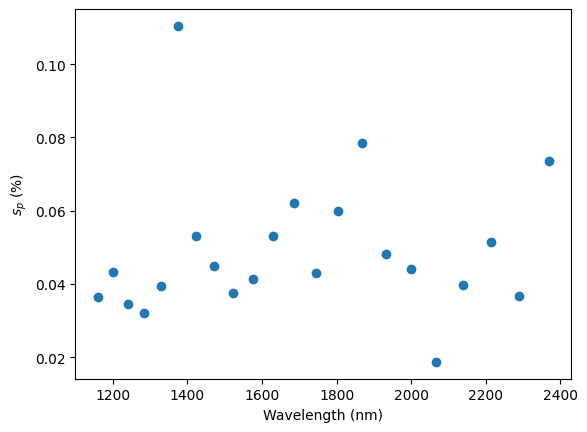

In [6]:
from pyPolCal.constants import wavelength_bins
import matplotlib.pyplot as plt

plt.scatter(wavelength_bins, s_p, label='s_p')
plt.xlabel('Wavelength (nm)')
plt.ylabel('$s_p$ (%)')

Text(0, 0.5, '$s_{\\chi}$ ($^\\circ$)')

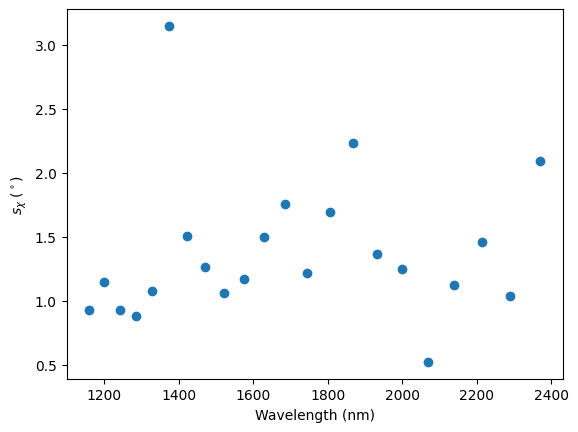

In [8]:
plt.scatter(wavelength_bins, s_chi, label='s_chi')
plt.xlabel('Wavelength (nm)')
plt.ylabel('$s_{\chi}$ ($^\circ$)')